# 04. NCO Comparsion

**Objective:** Evaluate and compare the performance of Hierarchical Equal Risk Contribution portfolios, and Nested Clustered Optimization portfolios that use the previously selected methods as inner and outer optimizers. Similarly to before we will evaluating the performance on the testing data, then we will perform an out of sample comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl
import warnings

warnings.filterwarnings("ignore")

from model_setup import HERC_models, choosen_classical_models, NCO_models

In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{lmodern} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{amssymb}",
        "font.family": "serif",
        "font.serif": ["Latin Modern Roman"],
    }
)

In [3]:
stock_data = pd.read_csv(
    "../data/raw/stock_data_comparison.csv", index_col=0, parse_dates=True
)

In [4]:
tested_HERC_models = []
tested_classical_models = []
tested_NCO_models = []

In [5]:
for model in HERC_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_HERC_models.append(testing_model)

In [6]:
for model in choosen_classical_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_classical_models.append(testing_model)

In [7]:
for model in NCO_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_NCO_models.append(testing_model)

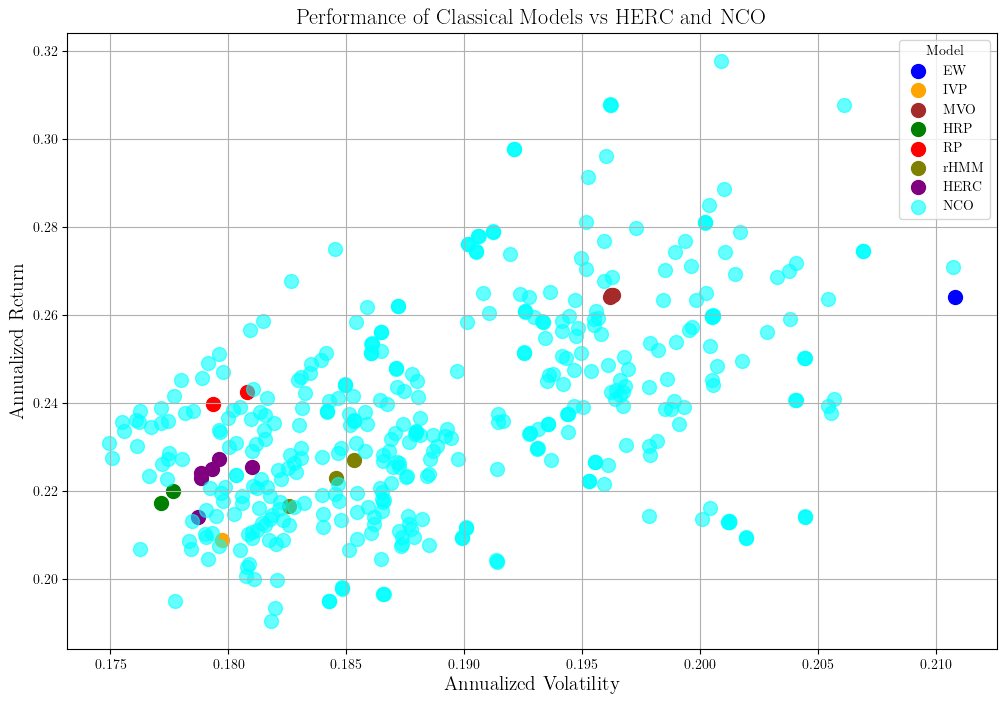

In [8]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs HERC and NCO", fontsize=16)

for i, model in enumerate(tested_classical_models):
    name = choosen_classical_models[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

for i, model in enumerate(tested_HERC_models):
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="HERC",
        color="purple",
        s=100,
    )

for i, model in enumerate(tested_NCO_models):
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="NCO",
        color="cyan",
        s=100,
        alpha=0.6,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

x_lim = plt.gca().get_xlim()
y_lim = plt.gca().get_ylim()

plt.show()

The HERC portfolios performed similarly to HRP and RP portfolios, thus provide a similarly safe option, albeit at a bit higher volatility than HRP. Interestingly however the NCO portfolios performance varied highly based on the specific type of inner and outer estimator involved. To gain a better understand let us also plot the result of the MC simulations.

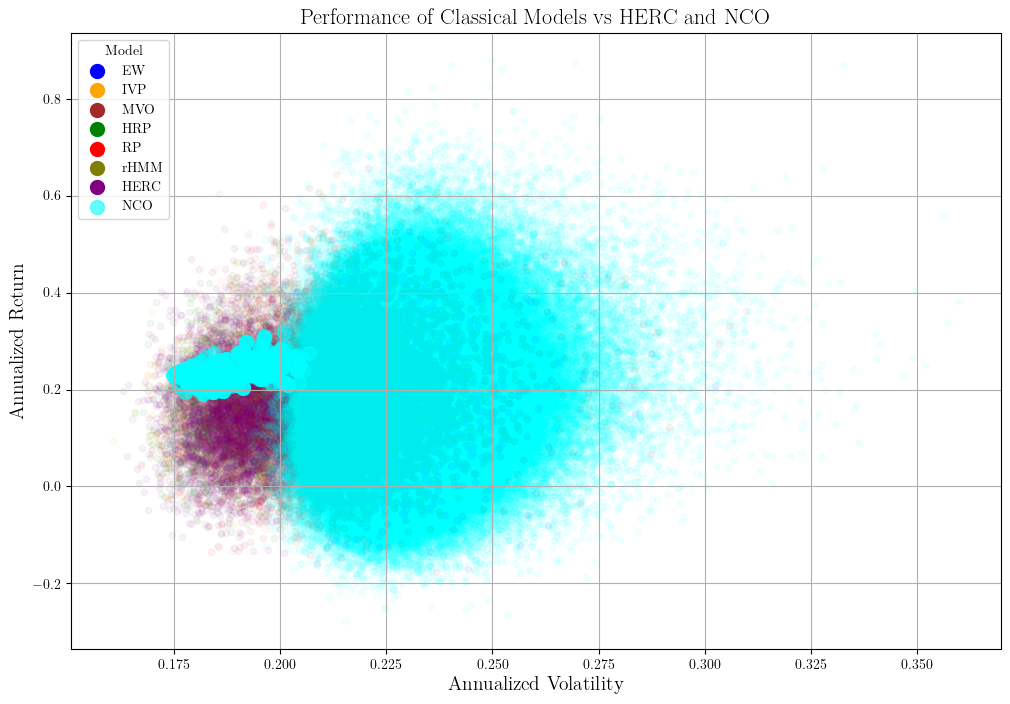

In [9]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs HERC and NCO", fontsize=16)

for i, model in enumerate(tested_classical_models):
    name = choosen_classical_models[i]["name"]

    with open(
        f"../data/rhmm_mvo_mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color=color,
    )

for i, model in enumerate(tested_HERC_models):

    name = HERC_models[i]["name"]

    with open(
        f"../data/mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="HERC",
        color="purple",
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color="purple",
    )

for i, model in enumerate(tested_NCO_models):

    name = NCO_models[i]["name"]

    with open(
        f"../data/mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="NCO",
        color="cyan",
        s=100,
        alpha=0.6,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color="cyan",
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

x_lim = plt.gca().get_xlim()
y_lim = plt.gca().get_ylim()

plt.show()

The MC Results paint a very similar picture to what we seen on the historical backtest. Let us now look at the performance metrics of the different models.

In [10]:
metrics_list = []
for i, model in enumerate(tested_classical_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/rhmm_mvo_mc_metrics/{choosen_classical_models[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = choosen_classical_models[i]["name"]
    metrics_list.append(metrics)


for i, model in enumerate(tested_HERC_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/mc_metrics/{HERC_models[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = HERC_models[i]["name"]
    metrics_list.append(metrics)


for i, model in enumerate(tested_NCO_models):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/mc_metrics/{NCO_models[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = NCO_models[i]["name"]
    metrics_list.append(metrics)


df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics = df_metrics.reindex(sorted(df_metrics.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Return Max,Annualized Return Mean,Annualized Return Min,Annualized Return Std,Annualized Volatility,Annualized Volatility Max,Annualized Volatility Mean,Annualized Volatility Min,Annualized Volatility Std,...,Sortino Ratio,Sortino Ratio Max,Sortino Ratio Mean,Sortino Ratio Min,Sortino Ratio Std,VAR (95%),VAR (95%) Max,VAR (95%) Mean,VAR (95%) Min,VAR (95%) Std
Model,,,,,,,,,,,,,,,,,,,,,
EW,0.2640,0.6569,0.1709,-0.1711,0.1179,0.2108,0.3025,0.2259,0.1912,0.0121,...,1.4535,4.8102,1.1717,-0.9393,0.8287,0.0188,0.0241,0.0200,0.0165,0.0010
NCO_kmeans_RP_FF_3_cov_rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2143,0.5811,0.1899,-0.1467,0.1172,0.1978,0.3051,0.2291,0.2003,0.0116,...,1.2282,4.2825,1.2920,-0.9235,0.8310,0.0178,0.0242,0.0203,0.0171,0.0010
NCO_kmeans_EW_MVO_max_sharpe_Carhart_4_cov_historical_ret,0.2141,0.6296,0.1904,-0.1254,0.1196,0.2044,0.2867,0.2294,0.2027,0.0119,...,1.1836,4.6225,1.2947,-0.6045,0.8451,0.0194,0.0248,0.0203,0.0169,0.0010
NCO_kmeans_EW_MVO_max_sharpe_FF_5_cov_historical_ret,0.2143,0.8270,0.1930,-0.1311,0.1224,0.2044,0.3016,0.2298,0.2009,0.0126,...,1.1844,5.5504,1.3184,-0.8058,0.8784,0.0194,0.0240,0.0203,0.0171,0.0010
NCO_kmeans_EW_MVO_max_sharpe_historical_cov_historical_ret,0.2142,0.6689,0.1933,-0.1535,0.1242,0.2044,0.2996,0.2294,0.1999,0.0122,...,1.1838,4.7233,1.3096,-0.9315,0.8731,0.0194,0.0238,0.0203,0.0173,0.0011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NCO_spectral_MVO_max_sharpe_FF_5_cov_historical_ret_MVO_max_sharpe_Carhart_4_cov_historical_ret,0.2452,0.6123,0.1822,-0.1459,0.1191,0.1966,0.2944,0.2282,0.1981,0.0119,...,1.4718,4.7165,1.2468,-0.7777,0.8459,0.0179,0.0233,0.0202,0.0174,0.0010
NCO_spectral_MVO_max_sharpe_FF_5_cov_historical_ret_MVO_max_sharpe_FF_5_cov_historical_ret,0.2424,0.5934,0.1795,-0.2785,0.1208,0.1968,0.3046,0.2279,0.1993,0.0131,...,1.4619,4.6074,1.2335,-1.8068,0.8579,0.0179,0.0233,0.0202,0.0172,0.0010
MVO_max_sharpe_historical_cov_historical_ret,0.2642,0.5997,0.1991,-0.1068,0.1171,0.1962,0.3033,0.2146,0.1785,0.0148,...,1.5972,5.1770,1.4503,-0.7728,0.9022,0.0178,0.0235,0.0188,0.0156,0.0011


We can gather very similar conclusions from the detailed metrics as well. In most metrics some kind of NCO strategy is performing better than the the other, previously examined strategies. Thus for further examination we will be using additionally the three best performing NCO for annualized return, Sharpe Ratio and max drawdown. This brings our model list to:

1. Equal weight portfolio

2. Inverse volatility weighted portfolio

3. Mean-variance portfolio with max sharpe objective, Carhart factor covariance estimator and historical return estimator

4. Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator

5. Mean-variance portfolio with max sharpe objective, Fama-French 5 factor covariance estimator and historical return estimator

6. Hierachical risk parity portfolio with with historical covariance estimator

7. Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator 

8. Risk parity portfolio with Fama-French 3 factor covariance estimator

9. Risk parity portfolio with Ledoit-Wolf covariance estimator

10. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, exponentially weighted covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator

11. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator and Risk parity portfolio with historical covariance estimator

12. rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, Fama-French 3 factor covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator

13. NCO portfolio with K-Means clustering, Mean-variance portfolio with max sharpe objective, Fama-French 5 factor covariance estimator and historical return estimator as the inner optimizer, and rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, Fama-French 3 factor covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator as the outer optimizer

14. NCO portfolio with K-Means clustering, rHMM-MVO-HRP portfolio with a Mean-variance portfolio with max sharpe objective, exponentially weighted covariance estimator and historical return estimator and Risk parity portfolio with Ledoit-Wolf covariance estimator as inner optimizer, Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator as the outer optimizer

15. NCO portfolio with K-Means clustering, Mean-variance portfolio with max sharpe objective, Carhart factor covariance estimator and historical return estimator as the inner optimizer, Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator as the outer optimizer

16. NCO portfolio with K-Means clustering, Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator as inner optimizer, Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator  as the outer optimizer.

17. NCO portfolio with K-Means clustering, Risk parity portfolio with Fama-French 3 factor covariance estimator as the inner optimier, Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator as the outer optimizer

18. NCO portfolio with Spectral clustering, Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator as the inner optimizer, Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator as the outer optimizer.

19. HERC portfolio with Carhart factor covariance estimator

20. HERC portfolio with Ledoit-Wolf covariance estimator

It is worth nothing that 2 out of the three best performing NCO models contain the previously developed rHMM model either in the inner or the outer optimizer.

In [11]:
from model_setup import choosen_NCO_models, choosen_HERC_models

In [12]:
tested_choosen_NCO_models = []
tested_choosen_HERC_models = []

In [13]:
for model in choosen_NCO_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_choosen_NCO_models.append(testing_model)

In [14]:
for model in choosen_HERC_models:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_choosen_HERC_models.append(testing_model)

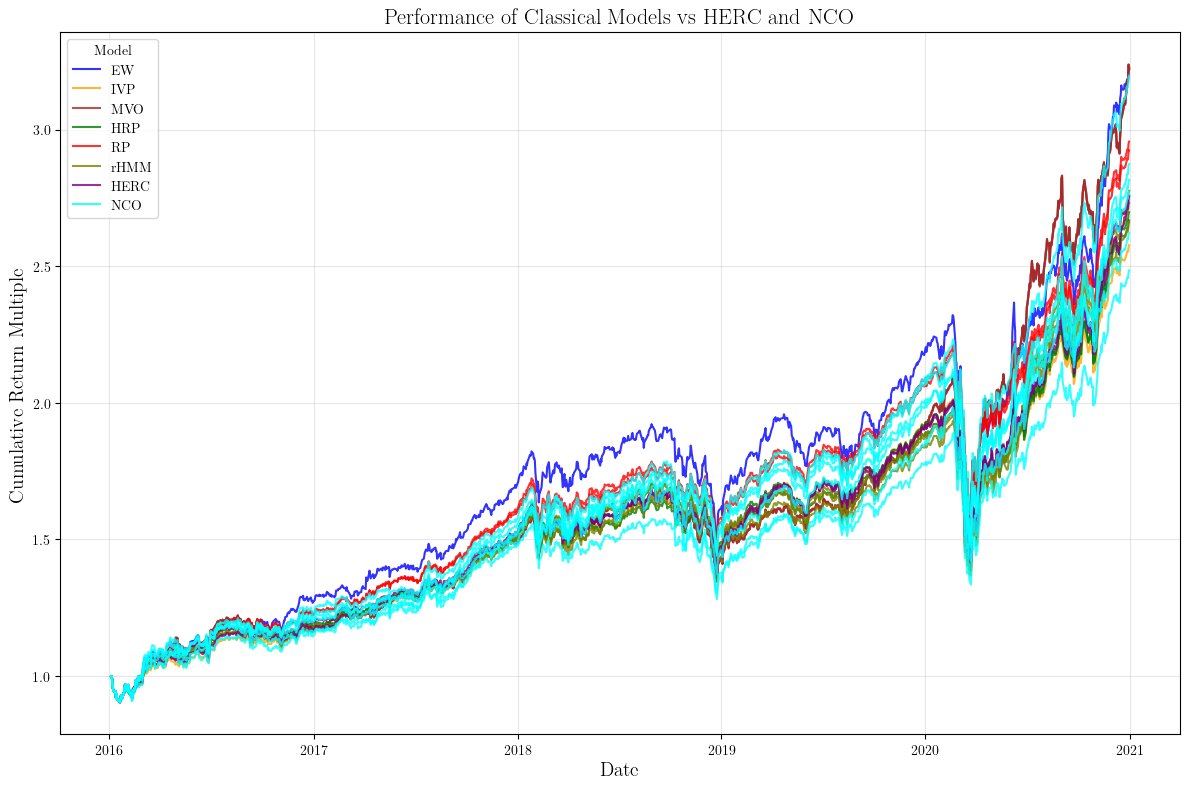

In [15]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs HERC and NCO", fontsize=16)

for i, model in enumerate(tested_classical_models):
    name = choosen_classical_models[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data.index,
        normalized_pv,
        label=name,
        alpha=0.8,
        linewidth=1.5,
        color=color,
    )

for i, model in enumerate(tested_choosen_HERC_models):

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data.index,
        normalized_pv,
        label="HERC",
        alpha=0.8,
        linewidth=1.5,
        color="purple",
    )


for i, model in enumerate(tested_choosen_NCO_models):

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data.index,
        normalized_pv,
        label="NCO",
        alpha=0.8,
        linewidth=1.5,
        color="cyan",
    )

plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return Multiple", fontsize=14)
plt.grid(True, alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

plt.tight_layout()
plt.show()

In [16]:
from model_setup import (
    choosen_NCO_models_oos,
    choosen_HERC_models_oos,
    choosen_classical_models_oos,
)

In [17]:
stock_data_oos = pd.read_csv(
    "../data/raw/stock_data_testing.csv", index_col=0, parse_dates=True
)

In [18]:
tested_choosen_NCO_models_oos = []
tested_choosen_HERC_models_oos = []
tested_classical_models_oos = []

In [19]:
for model in choosen_classical_models_oos:
    testing_model = model["class"](assets=stock_data_oos, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_classical_models_oos.append(testing_model)

In [20]:
for model in choosen_NCO_models_oos:
    testing_model = model["class"](assets=stock_data_oos, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_choosen_NCO_models_oos.append(testing_model)

In [21]:
for model in choosen_HERC_models_oos:
    testing_model = model["class"](assets=stock_data_oos, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_choosen_HERC_models_oos.append(testing_model)

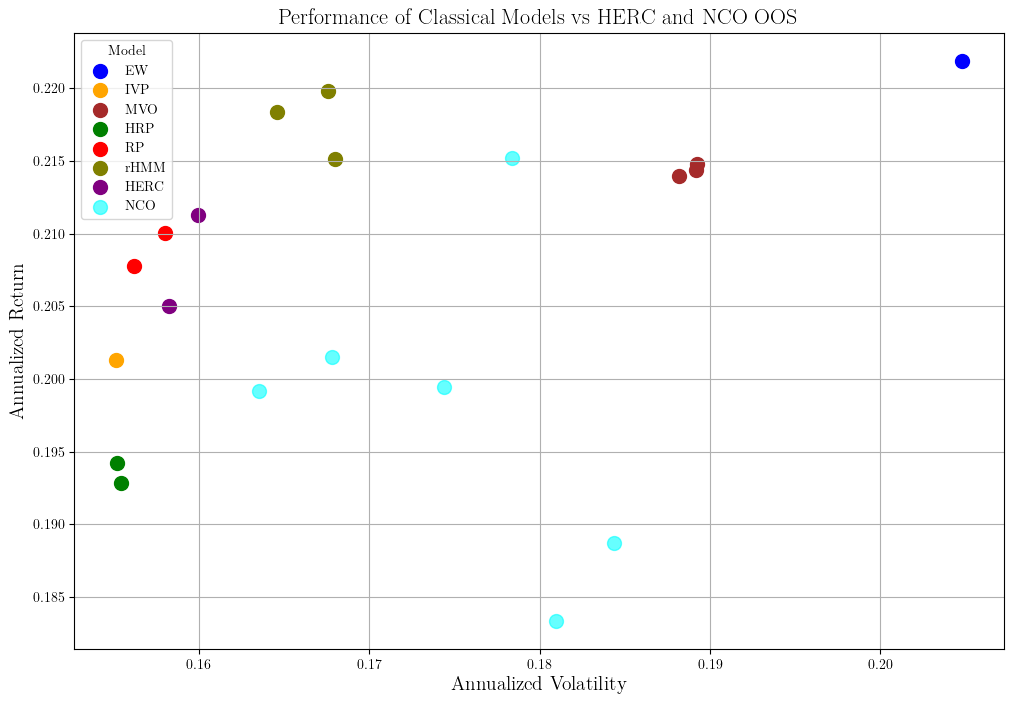

In [22]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs HERC and NCO OOS", fontsize=16)

for i, model in enumerate(tested_classical_models_oos):
    name = choosen_classical_models_oos[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

for i, model in enumerate(tested_choosen_HERC_models_oos):
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="HERC",
        color="purple",
        s=100,
    )

for i, model in enumerate(tested_choosen_NCO_models_oos):
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label="NCO",
        color="cyan",
        s=100,
        alpha=0.6,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

x_lim = plt.gca().get_xlim()
y_lim = plt.gca().get_ylim()

plt.show()

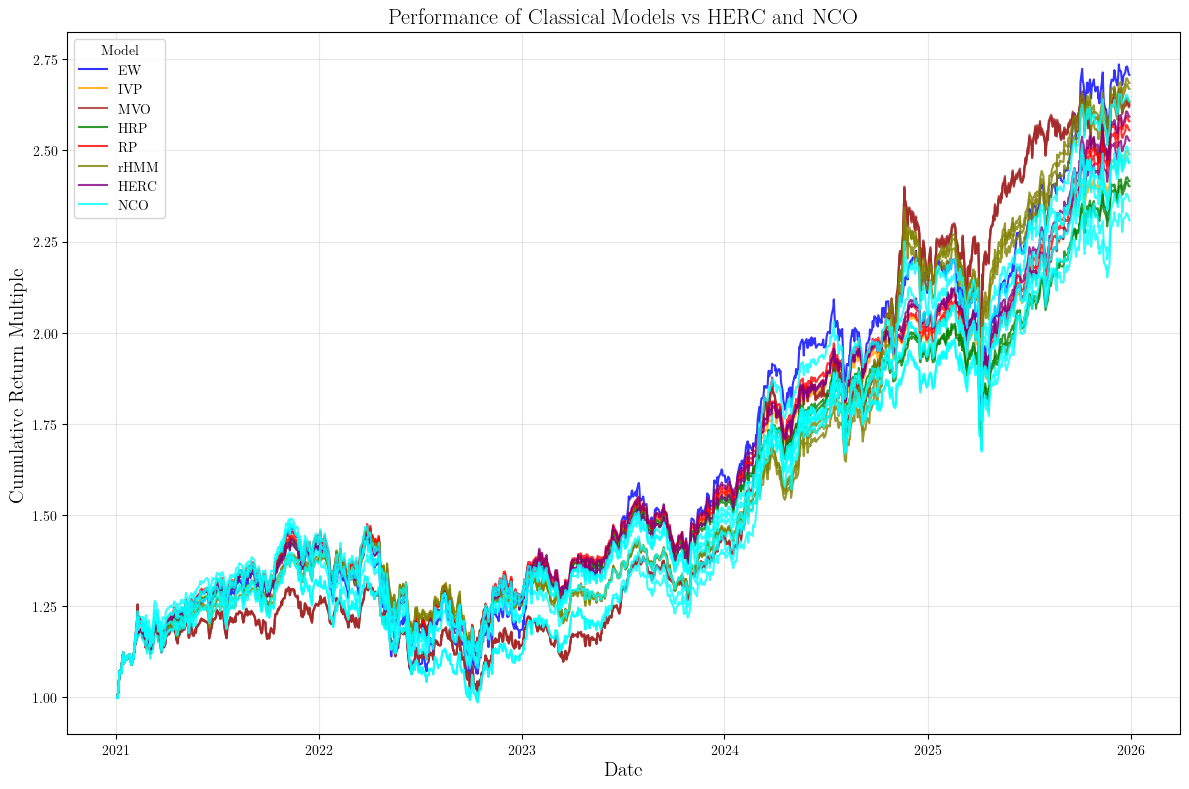

In [23]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models vs HERC and NCO", fontsize=16)

for i, model in enumerate(tested_classical_models_oos):
    name = choosen_classical_models_oos[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:3] == "MVO":
            name = "MVO"
        elif name[:4] == "rHMM":
            name = "rHMM"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO":
        color = "brown"
    elif name == "rHMM":
        color = "olive"

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data_oos.index,
        normalized_pv,
        label=name,
        alpha=0.8,
        linewidth=1.5,
        color=color,
    )

for i, model in enumerate(tested_choosen_HERC_models_oos):

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data_oos.index,
        normalized_pv,
        label="HERC",
        alpha=0.8,
        linewidth=1.5,
        color="purple",
    )


for i, model in enumerate(tested_choosen_NCO_models_oos):

    normalized_pv = model.portfolio_value / model.initial_capital

    plt.plot(
        stock_data_oos.index,
        normalized_pv,
        label="NCO",
        alpha=0.8,
        linewidth=1.5,
        color="cyan",
    )

plt.xlabel("Date", fontsize=14)
plt.ylabel("Cumulative Return Multiple", fontsize=14)
plt.grid(True, alpha=0.3)

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

plt.tight_layout()
plt.show()

Interestingly during 2021-2026 the classical models perform better on the historical backtest, possibly due to the stong bullish market during this time. To draw proper conclusions we need to examine the MC test metrics as well.

In [24]:
metrics_list = []
for i, model in enumerate(tested_classical_models_oos):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/oos_mc_metrics/{choosen_classical_models_oos[i]["name"]}_static_skewed_t_oos_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = choosen_classical_models_oos[i]["name"]
    metrics_list.append(metrics)


for i, model in enumerate(tested_choosen_HERC_models_oos):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/oos_mc_metrics/{choosen_HERC_models_oos[i]["name"]}_static_skewed_t_oos_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = choosen_HERC_models_oos[i]["name"]
    metrics_list.append(metrics)


for i, model in enumerate(tested_choosen_NCO_models_oos):

    metrics = model.performance_metrics.copy()

    with open(
        f"../data/oos_mc_metrics/{choosen_NCO_models_oos[i]["name"]}_static_skewed_t_oos_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = choosen_NCO_models_oos[i]["name"]
    metrics_list.append(metrics)


df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics = df_metrics.reindex(sorted(df_metrics.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Return Max,Annualized Return Mean,Annualized Return Min,Annualized Return Std,Annualized Volatility,Annualized Volatility Max,Annualized Volatility Mean,Annualized Volatility Min,Annualized Volatility Std,...,Sortino Ratio,Sortino Ratio Max,Sortino Ratio Mean,Sortino Ratio Min,Sortino Ratio Std,VAR (95%),VAR (95%) Max,VAR (95%) Mean,VAR (95%) Min,VAR (95%) Std
Model,,,,,,,,,,,,,,,,,,,,,
NCO_kmeans_MVO_max_sharpe_FF_5_cov_historical_ret_rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.1833,0.6760,0.2225,-0.1487,0.1238,0.1809,0.3061,0.2198,0.1907,0.0121,...,1.5087,4.7771,1.5616,-0.9035,0.9092,0.0180,0.0235,0.0194,0.0159,0.0010
NCO_kmeans_MVO_max_sharpe_Carhart_4_cov_historical_ret_MVO_max_sharpe_historical_cov_historical_ret,0.1888,0.6548,0.2124,-0.1192,0.1157,0.1844,0.2720,0.2203,0.1887,0.0116,...,1.5383,4.8819,1.4763,-0.7924,0.8428,0.0181,0.0228,0.0195,0.0167,0.0010
EW,0.2218,0.6850,0.2022,-0.1220,0.1242,0.2048,0.2728,0.2190,0.1864,0.0123,...,1.5928,5.6254,1.4215,-0.7887,0.9139,0.0190,0.0230,0.0194,0.0160,0.0010
NCO_kmeans_MVO_max_sharpe_historical_cov_historical_ret_HRP_ledoit_wolf_cov,0.1995,0.6209,0.2131,-0.1250,0.1190,0.1744,0.2905,0.2207,0.1922,0.0125,...,1.6881,5.2223,1.4947,-0.8313,0.8842,0.0168,0.0232,0.0194,0.0167,0.0010
NCO_kmeans_rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov_HRP_ledoit_wolf_cov,0.1992,0.6515,0.2105,-0.1344,0.1180,0.1635,0.2980,0.2199,0.1901,0.0124,...,1.7568,4.9758,1.4753,-0.9062,0.8814,0.0161,0.0226,0.0195,0.0161,0.0010
rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2184,0.5755,0.2152,-0.1253,0.1129,0.1646,0.2674,0.2052,0.1699,0.0148,...,1.9731,4.4284,1.6044,-0.9095,0.8852,0.0154,0.0215,0.0179,0.0139,0.0011
NCO_kmeans_RP_FF_3_cov_HRP_ledoit_wolf_cov,0.2015,0.6821,0.2205,-0.0886,0.1208,0.1678,0.2865,0.2192,0.1848,0.0121,...,1.7617,5.4004,1.5571,-0.5467,0.8973,0.0168,0.0228,0.0194,0.0168,0.0010
HERC_ledoit_wolf_cov,0.2051,0.5231,0.1892,-0.0571,0.0991,0.1582,0.2626,0.1897,0.1633,0.0121,...,1.8071,4.4800,1.5252,-0.4748,0.8470,0.0154,0.0202,0.0169,0.0142,0.0009
RP_ledoit_wolf_cov,0.2101,0.5261,0.1882,-0.0941,0.1010,0.1580,0.2717,0.1946,0.1705,0.0106,...,1.8747,4.6917,1.4780,-0.6201,0.8424,0.0154,0.0208,0.0173,0.0149,0.0009


In [25]:
df_metrics[
    [
        "Annualized Return",
        "Annualized Return Mean",
        "Annualized Volatility",
        "Annualized Volatility Mean",
        "Sharpe Ratio",
        "Sharpe Ratio Mean",
        "Max Drawdown",
        "Max Drawdown Mean",
    ]
].round(4)

,Annualized Return,Annualized Return Mean,Annualized Volatility,Annualized Volatility Mean,Sharpe Ratio,Sharpe Ratio Mean,Max Drawdown,Max Drawdown Mean
Model,,,,,,,,
NCO_kmeans_MVO_max_sharpe_FF_5_cov_historical_ret_rHMM_MVO_FF_3_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.1833,0.2225,0.1809,0.2198,1.0132,1.0101,0.2878,0.2785
NCO_kmeans_MVO_max_sharpe_Carhart_4_cov_historical_ret_MVO_max_sharpe_historical_cov_historical_ret,0.1888,0.2124,0.1844,0.2203,1.0237,0.9619,0.2877,0.2806
EW,0.2218,0.2022,0.2048,0.2190,1.0834,0.9206,0.2783,0.2880
NCO_kmeans_MVO_max_sharpe_historical_cov_historical_ret_HRP_ledoit_wolf_cov,0.1995,0.2131,0.1744,0.2207,1.1437,0.9639,0.2686,0.2862
NCO_kmeans_rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov_HRP_ledoit_wolf_cov,0.1992,0.2105,0.1635,0.2199,1.2178,0.9570,0.2481,0.2826
rHMM_MVO_ewma_MVO_cov_historical_MVO_ret_ledoit_wolf_HRP_cov,0.2184,0.2152,0.1646,0.2052,1.3266,1.0469,0.2414,0.2588
NCO_kmeans_RP_FF_3_cov_HRP_ledoit_wolf_cov,0.2015,0.2205,0.1678,0.2192,1.2008,1.0037,0.2390,0.2827
HERC_ledoit_wolf_cov,0.2051,0.1892,0.1582,0.1897,1.2958,0.9966,0.2343,0.2426
RP_ledoit_wolf_cov,0.2101,0.1882,0.1580,0.1946,1.3296,0.9668,0.2342,0.2522


The data supports our previous analysis. While NCO is competitive, especially when paired with the regime aware startegy developed previously, it falls behind in one or several metrics, despite the much higher computational cost. Thus we can conclude that our model performs the best on the data universe we have choosen in this case.